<a href="https://colab.research.google.com/github/MHzNug/Capstone-Project/blob/main/Model%20Klasifikasi%20Padi/Capstone_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===📦 Paket bawaan===
import os
import random
import shutil

# ===📊 Data dan visualisasi===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===🖼️ Pemrosesan gambar===
from PIL import Image
import cv2

# ===🤖 TensorFlow & Keras===
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D,
    Dense, Flatten, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras import Input
from keras.layers import TFSMLayer

# ===🧪 Utilities===
from sklearn.model_selection import train_test_split

# ===🌐 Kaggle Hub===
import kagglehub

In [2]:
rice_path = kagglehub.dataset_download("loki4514/rice-leaf-diseases-detection")
corn_path = kagglehub.dataset_download("smaranjitghose/corn-or-maize-leaf-disease-dataset")
potato_path = kagglehub.dataset_download("rizwan123456789/potato-disease-leaf-datasetpld")
cassava_path = kagglehub.dataset_download("nirmalsankalana/cassava-leaf-disease-classification")
tomato_path = kagglehub.dataset_download("kaustubhb999/tomatoleaf")

print("Rice dataset path:", rice_path)
print("Corn dataset path:", corn_path)
print("Potato dataset path:", potato_path)
print("Cassava dataset path:", cassava_path)
print("Tomato dataset path:", tomato_path)

100%|██████████| 37.4M/37.4M [00:01<00:00, 25.0MB/s]

Extracting files...


100%|██████████| 2.39G/2.39G [00:59<00:00, 42.8MB/s]

Extracting files...


100%|██████████| 179M/179M [00:05<00:00, 36.9MB/s]

Extracting files...


Rice dataset path: /kaggle/input/rice-leaf-diseases-detection
Corn dataset path: /kaggle/input/corn-or-maize-leaf-disease-dataset
Potato dataset path: /root/.cache/kagglehub/datasets/rizwan123456789/potato-disease-leaf-datasetpld/versions/1
Cassava dataset path: /root/.cache/kagglehub/datasets/nirmalsankalana/cassava-leaf-disease-classification/versions/2
Tomato dataset path: /root/.cache/kagglehub/datasets/kaustubhb999/tomatoleaf/versions/1


In [3]:
combined_path = 'combined_dataset'
os.makedirs(combined_path, exist_ok=True)

In [4]:
def copy_images_with_crop_prefix(src_dir, dst_root, crop_prefix="", use_crop_prefix=True):
    for class_name in os.listdir(src_dir):
        class_path = os.path.join(src_dir, class_name)
        if os.path.isdir(class_path):
            if use_crop_prefix:
                dst_class = f"{crop_prefix}___{class_name.replace(' ', '_')}"
            else:
                dst_class = class_name.replace(' ', '_')

            dst_class_path = os.path.join(dst_root, dst_class)
            os.makedirs(dst_class_path, exist_ok=True)

            for img_name in os.listdir(class_path):
                src_img = os.path.join(class_path, img_name)
                dst_img = os.path.join(dst_class_path, img_name)

                # Rename if file already exists
                if os.path.exists(dst_img):
                    base, ext = os.path.splitext(img_name)
                    i = 1
                    while os.path.exists(dst_img):
                        new_name = f"{base}_{i}{ext}"
                        dst_img = os.path.join(dst_class_path, new_name)
                        i += 1

                shutil.copy(src_img, dst_img)


# Rice dataset
copy_images_with_crop_prefix(os.path.join(rice_path, 'Rice_Leaf_Diease/Rice_Leaf_Diease/train'), combined_path, "Rice")

# Corn dataset
copy_images_with_crop_prefix(os.path.join(corn_path, 'data'), combined_path, "Corn")

# Potato dataset
copy_images_with_crop_prefix(os.path.join(potato_path, 'PLD_3_Classes_256/Training'), combined_path, 'Potato')

# Cassava dataset
copy_images_with_crop_prefix(os.path.join(cassava_path, 'data'), combined_path, use_crop_prefix=False)

# Tomato dataset
copy_images_with_crop_prefix(os.path.join(tomato_path, 'tomato/train'), combined_path, use_crop_prefix=False)

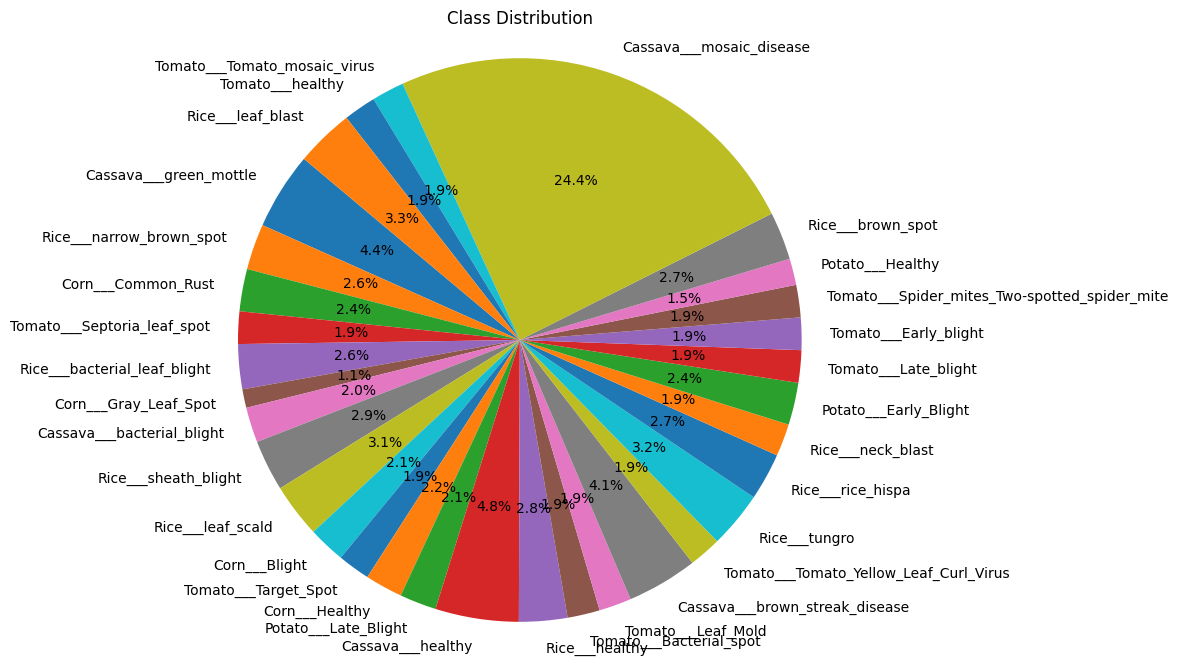

In [5]:
# Ambil nama-nama kelas (subfolder)
class_names = [d for d in os.listdir(combined_path) if os.path.isdir(os.path.join(combined_path, d))]

# Hitung jumlah gambar per kelas
class_counts = []
for class_name in class_names:
    class_path = os.path.join(combined_path, class_name)
    image_files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    class_counts.append(len(image_files))

# Plot Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=class_names, autopct='%1.1f%%', startangle=140)
plt.title('Class Distribution')
plt.axis('equal')
plt.show()

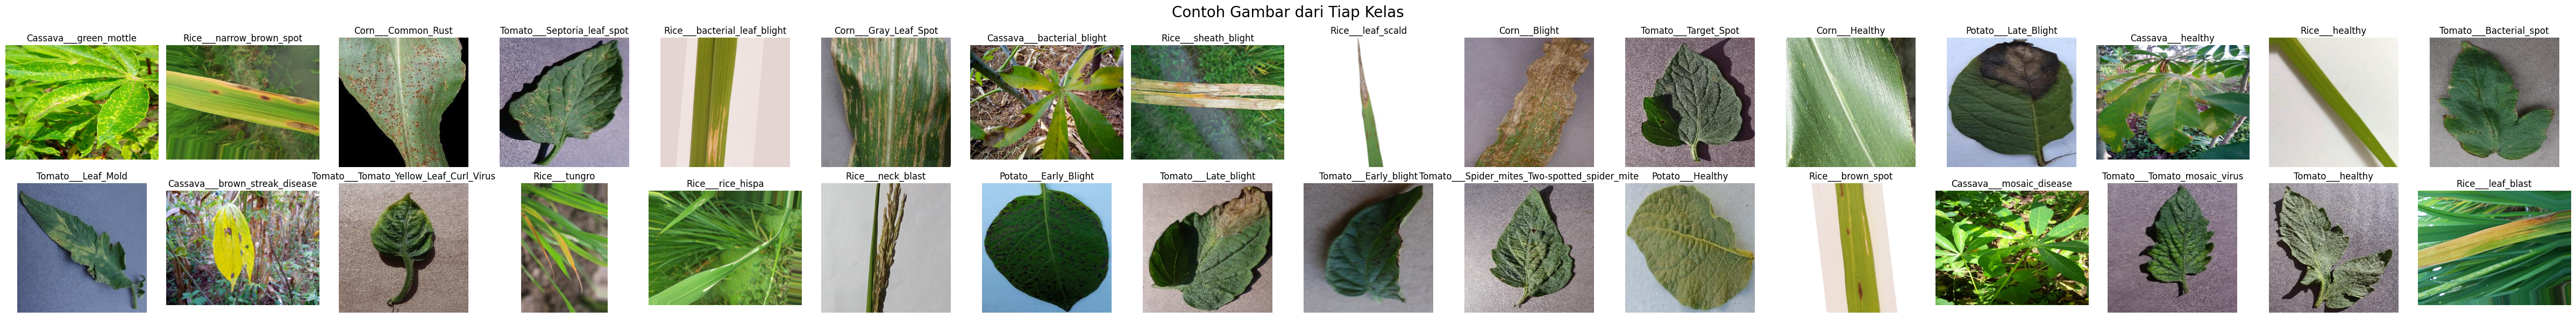

In [6]:
n_classes = len(class_names)

# Ukuran grid subplot
n_rows = 2
n_cols = int(np.ceil(n_classes / n_rows))

# Buat subplot
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axs = axs.flatten()  # ubah ke array 1 dimensi agar mudah di-loop

for i, ax in enumerate(axs):
    if i >= n_classes:
        ax.axis('off')  # kosongkan sisa plot jika subplot lebih banyak dari kelas
        continue

    class_name = class_names[i]
    class_path = os.path.join(combined_path, class_name)

    # Ambil semua path gambar yang valid
    image_paths = [
        os.path.join(class_path, img)
        for img in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, img)) and img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Tampilkan gambar acak dari kelas ini
    if image_paths:
        img = cv2.imread(random.choice(image_paths))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(class_name)
    ax.axis('off')

plt.suptitle("Contoh Gambar dari Tiap Kelas", fontsize=20)
plt.tight_layout()
plt.show()

In [7]:
def split_dataset(
    src_folder,
    dest_folder,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=42
):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-5, "Total rasio harus 1.0"

    random.seed(seed)

    class_names = [d for d in os.listdir(src_folder) if os.path.isdir(os.path.join(src_folder, d))]

    for class_name in class_names:
        src_class_path = os.path.join(src_folder, class_name)
        images = [
            f for f in os.listdir(src_class_path)
            if os.path.isfile(os.path.join(src_class_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(train_ratio * n_total)
        n_val = int(val_ratio * n_total)
        n_test = n_total - n_train - n_val

        splits = {
            'train': images[:n_train],
            'val': images[n_train:n_train + n_val],
            'test': images[n_train + n_val:]
        }

        for split_name, split_images in splits.items():
            dest_class_path = os.path.join(dest_folder, split_name, class_name)
            os.makedirs(dest_class_path, exist_ok=True)

            for img_name in split_images:
                src_img_path = os.path.join(src_class_path, img_name)
                dst_img_path = os.path.join(dest_class_path, img_name)

                shutil.copy2(src_img_path, dst_img_path)

    print(f"Selesai split dataset ke dalam folder: {dest_folder}")

# Jalankan split
split_dataset(
    src_folder='combined_dataset',
    dest_folder='split_dataset',
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)

Selesai split dataset ke dalam folder: split_dataset


In [9]:
from collections import defaultdict
split_dir = os.path.join(os.getcwd(), 'split_dataset')

train_path = os.path.join(split_dir, 'train')

class_counts = defaultdict(int)
for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)
    if os.path.isdir(class_folder):
        class_counts[class_name] = len(os.listdir(class_folder))

display(class_counts)

defaultdict(int,
            {'Cassava___green_mottle': 1670,
             'Rice___narrow_brown_spot': 991,
             'Corn___Common_Rust': 914,
             'Tomato___Septoria_leaf_spot': 700,
             'Rice___bacterial_leaf_blight': 970,
             'Corn___Gray_Leaf_Spot': 401,
             'Cassava___bacterial_blight': 760,
             'Rice___sheath_blight': 1104,
             'Rice___leaf_scald': 1169,
             'Corn___Blight': 802,
             'Tomato___Target_Spot': 700,
             'Corn___Healthy': 813,
             'Potato___Late_Blight': 792,
             'Cassava___healthy': 1803,
             'Rice___healthy': 1043,
             'Tomato___Bacterial_spot': 700,
             'Tomato___Leaf_Mold': 700,
             'Cassava___brown_streak_disease': 1532,
             'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 700,
             'Rice___tungro': 1218,
             'Rice___rice_hispa': 1022,
             'Rice___neck_blast': 700,
             'Potato___Early_Bligh

In [10]:
min_count = min(class_counts.values())  # atau nilai lain sesuai keinginan
print("Target gambar per kelas setelah undersampling:", min_count)

Target gambar per kelas setelah undersampling: 401


In [11]:
for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)
    if os.path.isdir(class_folder):
        images = os.listdir(class_folder)
        if len(images) > min_count:
            to_remove = random.sample(images, len(images) - min_count)
            for img_name in to_remove:
                os.remove(os.path.join(class_folder, img_name))

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=60,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_gen = train_datagen.flow_from_directory(
    os.path.join(split_dir, 'train'),
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    os.path.join(split_dir, 'test'),
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

val_datagen = ImageDataGenerator(rescale=1./255)
val_gen = val_datagen.flow_from_directory(
    os.path.join(split_dir, 'val'),
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 12832 images belonging to 32 classes.
Found 8097 images belonging to 32 classes.
Found 8069 images belonging to 32 classes.


In [16]:
class StopTrainingAtAccuracy(Callback):
    def __init__(self, acc_threshold=0.95, val_acc_threshold=0.95):
        super(StopTrainingAtAccuracy, self).__init__()
        self.acc_threshold = acc_threshold
        self.val_acc_threshold = val_acc_threshold

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get("accuracy")
        val_acc = logs.get("val_accuracy")
        if acc is not None and val_acc is not None:
            if acc >= self.acc_threshold and val_acc >= self.val_acc_threshold:
                print(f"\n Target tercapai! Akurasi dan val_akurasi >= {self.acc_threshold * 100:.0f}%")
                self.model.stop_training = True

In [22]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation = 'relu', padding = 'same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
callback = [
    StopTrainingAtAccuracy(),
    ModelCheckpoint('model_checkpoint.keras', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, verbose=1),
]

history = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=callback,
    verbose=1
)

Epoch 1/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.0894 - loss: 3.1237
Epoch 1: val_loss improved from inf to 1.87349, saving model to model_checkpoint.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 233s 575ms/step - accuracy: 0.0896 - loss: 3.1227 - val_accuracy: 0.2904 - val_loss: 1.8735
Epoch 2/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.3209 - loss: 1.9396
Epoch 2: val_loss did not improve from 1.87349
401/401 ━━━━━━━━━━━━━━━━━━━━ 244s 609ms/step - accuracy: 0.3210 - loss: 1.9394 - val_accuracy: 0.4010 - val_loss: 2.0457
Epoch 3/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.4128 - loss: 1.6411
Epoch 3: val_loss improved from 1.87349 to 1.54655, saving model to model_checkpoint.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 221s 551ms/step - accuracy: 0.4129 - loss: 1.6409 - val_accuracy: 0.3772 - val_loss: 1.5466
Epoch 4/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.4829 - loss: 1.4392
Epoch 4: val_loss improved from 1.54655 to 1.54197, saving m

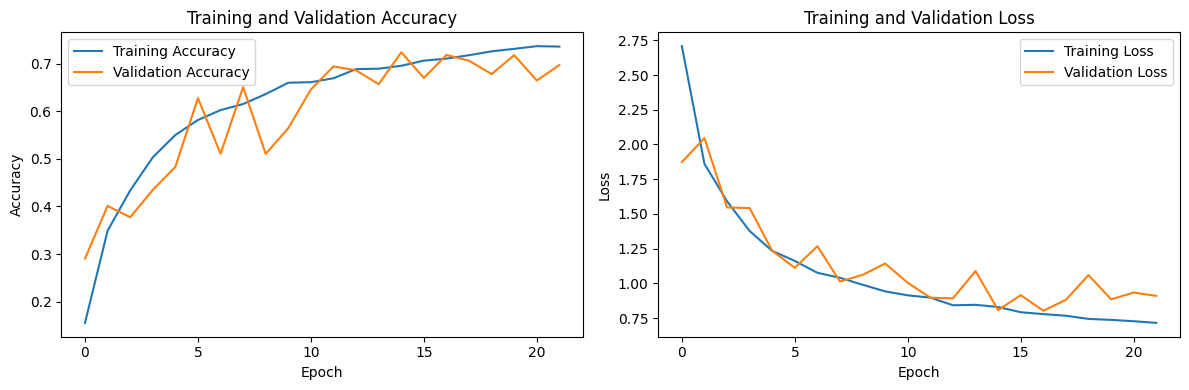

In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import classification_report

# Dapatkan label asli
true_labels = test_gen.classes

# Dapatkan label prediksi
pred_probs = model.predict(test_gen, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)

# Label nama kelas
class_names = list(test_gen.class_indices.keys())

# Classification report
print("Classification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=class_names))

254/254 ━━━━━━━━━━━━━━━━━━━━ 43s 170ms/step
Classification Report:

                                               precision    recall  f1-score   support

                   Cassava___bacterial_blight       0.02      0.02      0.02       164
               Cassava___brown_streak_disease       0.03      0.10      0.05       329
                       Cassava___green_mottle       0.07      0.06      0.07       359
                            Cassava___healthy       0.00      0.00      0.00       388
                     Cassava___mosaic_disease       0.25      0.24      0.24      1975
                                Corn___Blight       0.03      0.02      0.03       173
                           Corn___Common_Rust       0.03      0.03      0.03       197
                        Corn___Gray_Leaf_Spot       0.02      0.02      0.02        87
                               Corn___Healthy       0.01      0.01      0.01       175
                        Potato___Early_Blight       0.03     

In [21]:
loss, acc = model.evaluate(test_gen)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

254/254 ━━━━━━━━━━━━━━━━━━━━ 43s 170ms/step - accuracy: 0.7023 - loss: 0.7751
Test Loss: 0.7795, Test Accuracy: 0.7047


In [ ]:
!pip install tensorflowjs

In [ ]:
model.save("/content/my_model.keras")

In [ ]:
model.save("/content/my_model.h5")

In [ ]:
!tensorflowjs_converter \
    --input_format=keras \
    my_model.h5 \
    tfjs_model/

2025-05-07 09:36:40.086057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746610600.107389   20682 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746610600.113890   20682 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
failed to lookup keras version from the file,
    this is likely a weight only file


In [ ]:
from google.colab import files

!zip -r tfjs_model.zip tfjs_model
files.download("tfjs_model.zip")

  adding: tfjs_model/ (stored 0%)
  adding: tfjs_model/group1-shard1of6.bin (deflated 7%)
  adding: tfjs_model/model.json (deflated 86%)
  adding: tfjs_model/group1-shard3of6.bin (deflated 7%)
  adding: tfjs_model/group1-shard4of6.bin (deflated 7%)
  adding: tfjs_model/group1-shard5of6.bin (deflated 7%)
  adding: tfjs_model/group1-shard6of6.bin (deflated 7%)
  adding: tfjs_model/group1-shard2of6.bin (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# SavedModel (untuk TFLite & TFJS)
model.export('/content//saved_model')

# TFLite
converter = tf.lite.TFLiteConverter.from_saved_model('/content/saved_model')
tflite_model = converter.convert()
with open('/content/model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/content//saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135299081468816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135299081463824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135299081467664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135299081469584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135299081464016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135299081466896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135299081468624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135299019133520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135299019140816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135299019142160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13529901

In [ ]:
!zip -r saved_model.zip saved_model
files.download("saved_model.zip")

  adding: saved_model/ (stored 0%)
  adding: saved_model/saved_model.pb (deflated 85%)
  adding: saved_model/assets/ (stored 0%)
  adding: saved_model/fingerprint.pb (stored 0%)
  adding: saved_model/variables/ (stored 0%)
  adding: saved_model/variables/variables.index (deflated 64%)
  adding: saved_model/variables/variables.data-00000-of-00001 (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step
Keys dari hasil prediksi: dict_keys(['output_0'])


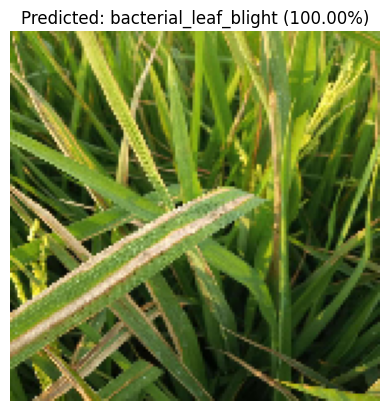

In [ ]:
# --- Load gambar test ---
img_path = '/content/dataset/test/bacterial_leaf_blight/1601885203_image2.jpg'  # gambar test
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.
img_array = np.expand_dims(img_array, axis=0)

# --- Load SavedModel sebagai Layer ---
saved_model_path = "/content/saved_model"
model_loaded = TFSMLayer(saved_model_path, call_endpoint="serving_default")

# --- Bungkus dalam Model baru ---
input_layer = Input(shape=img_array.shape[1:])
output_layer = model_loaded(input_layer)
model = Model(inputs=input_layer, outputs=output_layer)

# --- Inference ---
pred_dict = model.predict(img_array)

# --- Cek key dari dict ---
print("Keys dari hasil prediksi:", pred_dict.keys())  # dict_keys(['output_0'])

# Ambil nilai array prediksi dari dict
pred = list(pred_dict.values())[0]

# --- Ambil kelas dan confidence ---
predicted_class = list(train_gen.class_indices.keys())[np.argmax(pred)]
confidence = np.max(pred) * 100

# --- Tampilkan Gambar + Prediksi ---
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
plt.show()
